In [ ]:
import os
import time
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Environment & Reproducibility Setup
!pip install -q torch torchvision matplotlib numpy scipy pandas scikit-learn tqdm

SEED = 42
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

# 2. Global Configurations
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
%matplotlib inline
plt.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 300})

print(f"Environment initialized.")
print(f"Device: {device}")
print(f"Global SEED: {SEED} (Deterministic mode enabled)")

Environment initialized.
Device: cuda
Global SEED: 42 (Deterministic mode enabled)


In [2]:
# Cell 1: Clone Korotin/Wasserstein2Benchmark (idempotent)
import os, shutil

BENCH_REPO = "/content/Wasserstein2Benchmark"

# Only clone if benchmarks/ subdirectory is absent
# (handles re-run and partially-cloned sessions)
if not os.path.isdir(os.path.join(BENCH_REPO, "benchmarks")):
    if os.path.exists(BENCH_REPO):
        shutil.rmtree(BENCH_REPO)   # wipe broken partial clone
    print("Cloning Wasserstein2Benchmark...")
    os.system("git clone https://github.com/iamalexkorotin/Wasserstein2Benchmark.git " + BENCH_REPO)
else:
    print("Wasserstein2Benchmark already present with benchmarks/ OK")

# Verify
assert os.path.isdir(os.path.join(BENCH_REPO, "benchmarks")), f"Clone failed: {BENCH_REPO}/benchmarks not found"
print("benchmarks/ directory verified OK")

!pip install -q pot


Cloning into 'Wasserstein2Benchmark'...
remote: Enumerating objects: 126, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 126 (delta 14), reused 9 (delta 3), pack-reused 104 (from 1)
Receiving objects: 100% (126/126), 904.41 MiB | 26.20 MiB/s, done.
Resolving deltas: 100% (22/22), done.
Updating files: 100% (85/85), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 69.5 MB/s eta 0:00:00


*Redundant seed configuration removed to maintain a single source of truth in the Setup section.*

# Optimal Transport using Input-Convex Neural Networks (ICNN)

This notebook contains a self-contained, high-performance implementation of the Input-Convex Neural Network (ICNN) solver for optimal transport under quadratic costs ($W_2$), reproducing the minimax dual formulation by Makkuva et al. (2020).

## Core Theoretical Concepts
1. **Monge-Kantorovich Dual**: We find the optimal transport mapping by optimizing dual potentials.
2. **Brenier's Theorem**: For quadratic costs, the optimal transport map is unique and given by the gradient of a convex potential $\nabla \varphi$.
3. **ICNN**: Amos et al. (2017) enforce convexity of the network $\varphi$ by restricting its hidden weights to be non-negative and using convex, non-decreasing activations.

Run the cells below sequentially to load the models, define the objectives, and execute the paper reproductions and failure-mode analyses.


### Global Definitions

All core libraries, device configurations, and reproducibility seeds have been centralized in the setup section to ensure consistent results across all environments.

## 1. Network Architectures
We define both the `ICNN` (with weight clipping to preserve convexity) and `StandardMLP` (used as a non-convex failure-mode comparison).


In [3]:
class StandardMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=(64, 64, 64), activation='softplus'):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dims = list(hidden_dims)
        self.act = {
            'softplus': nn.Softplus(),
            'relu': nn.ReLU(),
            'leaky_relu': nn.LeakyReLU(0.2),
            'elu': nn.ELU(),
        }[activation]

        dims = [input_dim] + self.hidden_dims + [1]
        self.layers = nn.ModuleList()
        for i in range(len(dims) - 1):
            self.layers.append(nn.Linear(dims[i], dims[i + 1]))

    def forward(self, x):
        h = x
        for i, layer in enumerate(self.layers):
            h = layer(h)
            if i < len(self.layers) - 1:
                h = self.act(h)
        return h.squeeze(-1)

    @torch.no_grad()
    def clip_weights(self):
        pass

    def grad(self, y):
        y = y.clone().requires_grad_(True)
        with torch.enable_grad():
            f_val = self.forward(y)
            (grad_y,) = torch.autograd.grad(f_val.sum(), y, create_graph=True)
        return grad_y

class ICNN(nn.Module):
    def __init__(self, input_dim, hidden_dims=(64, 64, 64), activation='softplus'):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dims = list(hidden_dims)
        self.act = {
            'softplus': nn.Softplus(),
            'relu': nn.ReLU(),
            'leaky_relu': nn.LeakyReLU(0.2),
            'elu': nn.ELU(),
        }[activation]

        dims = [input_dim] + self.hidden_dims + [1]
        self.Wy = nn.ModuleList()
        self.Wz = nn.ModuleList()
        for i in range(len(dims) - 1):
            out_d = dims[i + 1]
            self.Wy.append(nn.Linear(input_dim, out_d, bias=True))
            self.Wz.append(None if i == 0 else nn.Linear(self.hidden_dims[i - 1], out_d, bias=False))

    def forward(self, y):
        z = self.act(self.Wy[0](y))
        for i in range(1, len(self.Wy)):
            pre_act = self.Wz[i](z) + self.Wy[i](y)
            z = pre_act if i == len(self.Wy) - 1 else self.act(pre_act)
        return z.squeeze(-1)

    @torch.no_grad()
    def clip_weights(self):
        for layer in self.Wz:
            if layer is not None:
                layer.weight.data.clamp_(min=0)

    def grad(self, y):
        y = y.clone().requires_grad_(True)
        with torch.enable_grad():
            f_val = self.forward(y)
            (grad_y,) = torch.autograd.grad(f_val.sum(), y, create_graph=True)
        return grad_y

## 2. Minimax Loss Formulation
We implement the minimax dual objective from Section 3 of Makkuva et al. (2020).


In [4]:
def minimax_loss(f, g, x_mu, y_nu):
    grad_g_y = g.grad(y_nu)
    term_mu = f(x_mu).mean()
    term_nu = (y_nu * grad_g_y).sum(dim=1).mean() - f(grad_g_y).mean()
    f_loss = term_mu + term_nu
    g_loss = -term_nu
    return f_loss, g_loss


## 3. Training Loop
A dataset-agnostic training loop that updates $f$ and $g$ alternatingly using the Adam optimizer.


In [5]:
def train_icnn_ot(mu_sampler, nu_sampler, input_dim, n_iters=1500, batch_size=256,
                   hidden_dims=(128, 128, 128), lr=1e-3, inner_iters=10, device=None,
                   activation='softplus', log_every=300, model_type='icnn'):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    else:
        device = torch.device(device)

    torch.manual_seed(0)
    if model_type.lower() == 'icnn':
        f = ICNN(input_dim, hidden_dims, activation=activation).to(device)
        g = ICNN(input_dim, hidden_dims, activation=activation).to(device)
    else:
        f = StandardMLP(input_dim, hidden_dims, activation=activation).to(device)
        g = StandardMLP(input_dim, hidden_dims, activation=activation).to(device)

    opt_f = torch.optim.Adam(f.parameters(), lr=lr, betas=(0.5, 0.9))
    opt_g = torch.optim.Adam(g.parameters(), lr=lr, betas=(0.5, 0.9))
    history = {'f_loss': []}
    start_time = time.time()

    for it in range(n_iters):
        # 1. Update potential g (inner maximization loop)
        for _ in range(inner_iters):
            x_mu, y_nu = mu_sampler(batch_size).to(device), nu_sampler(batch_size).to(device)
            _, g_loss = minimax_loss(f, g, x_mu, y_nu)
            opt_g.zero_grad()
            g_loss.backward()
            opt_g.step()
            g.clip_weights()

        # 2. Update potential f (outer minimization loop)
        x_mu, y_nu = mu_sampler(batch_size).to(device), nu_sampler(batch_size).to(device)
        f_loss, _ = minimax_loss(f, g, x_mu, y_nu)
        opt_f.zero_grad()
        f_loss.backward()
        opt_f.step()
        f.clip_weights()

        history['f_loss'].append(f_loss.item())

        # Enhanced logging to ensure the final iteration is always visible
        if it % log_every == 0 or it == n_iters - 1:
            print(f'Iteration {it:4d} | f_loss = {f_loss.item():.4f}')

    end_time = time.time()
    training_time = end_time - start_time
    final_f_loss = history['f_loss'][-1]

    return f, g, history, final_f_loss, training_time

## 4. Distribution Samplers
Definitions of various source ($\mu$) and target ($
u$) samplers, including Gaussians, mixtures on circles, and disconnected support.


In [6]:
def make_gaussian_sampler(mu, sigma, device='cpu'):
    def sampler(batch_size):
        return torch.randn(batch_size, len(mu), device=device) * sigma + torch.tensor(mu, device=device)
    return sampler

def make_mixture_sampler(means, covariances, weights, device='cpu'):
    means = [torch.tensor(m, device=device, dtype=torch.float32) for m in means]
    covariances = [torch.tensor(c, device=device, dtype=torch.float32) for c in covariances]
    weights = np.array(weights, dtype=np.float32) / sum(weights)

    def sampler(batch_size):
        idx = np.random.choice(len(weights), size=batch_size, p=weights)
        samples = []
        for k in range(len(weights)):
            n = int((idx == k).sum())
            if n == 0: continue
            z = torch.randn(n, means[0].shape[0], device=device)
            L = torch.linalg.cholesky(covariances[k])
            samples.append((z @ L.T) + means[k])
        return torch.cat(samples, dim=0)
    return sampler

def make_disconnected_sampler(means, sigma, device='cpu'):
    means = [torch.tensor(m, device=device, dtype=torch.float32) for m in means]
    def sampler(batch_size):
        idx = np.random.choice(len(means), size=batch_size)
        samples = []
        for k in range(len(means)):
            n = int((idx == k).sum())
            if n == 0: continue
            z = torch.randn(n, len(means[k]), device=device)
            samples.append(z * sigma + means[k])
        return torch.cat(samples, dim=0)
    return sampler

def make_finite_pool_sampler(pool):
    def sampler(batch_size):
        idx = torch.randint(0, len(pool), (batch_size,), device=pool.device)
        return pool[idx]
    return sampler


## 5. Visualization Helpers
Helper functions to render distribution scatters, learned transport maps, and displacement vector fields.


In [7]:
def plot_reproduction_results(mu_sampler, nu_sampler, f, g, title_suffix='', filename_suffix=''):
    n_plot = 300
    x_plot_tensor = mu_sampler(n_plot).detach()
    y_plot_tensor = nu_sampler(n_plot).detach()

    model_device = next(g.parameters()).device

    # Ensure gradients are enabled for the transport map calculation
    with torch.enable_grad():
        y_plot_tensor_g = y_plot_tensor.clone().to(model_device).requires_grad_(True)
        transport_tensor = g.grad(y_plot_tensor_g)
        transport = transport_tensor.detach().cpu().numpy()

    x_plot = x_plot_tensor.cpu().numpy()
    y_plot = y_plot_tensor.cpu().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    # 1. Source vs Target Scatter - Using raw strings for LaTeX
    axes[0].scatter(x_plot[:, 0], x_plot[:, 1], s=15, alpha=0.6, label=r'Source $\mu$', color='C0')
    axes[0].scatter(y_plot[:, 0], y_plot[:, 1], s=15, alpha=0.6, label=r'Target $\nu$', color='C1')
    axes[0].set_title(f'Distributions {title_suffix}')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.5)

    # 2. Transport Mapping
    axes[1].scatter(y_plot[:, 0], y_plot[:, 1], s=15, alpha=0.5, label=r'Target $y$', color='C1')
    axes[1].scatter(transport[:, 0], transport[:, 1], s=15, alpha=0.5, label=r'Transport $T(y)$', color='C2')
    axes[1].set_title(f'Learned Map {title_suffix}')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.5)

    # 3. Vector displacement field
    step = max(1, n_plot // 80)
    axes[2].quiver(
        y_plot[::step, 0], y_plot[::step, 1],
        transport[::step, 0] - y_plot[::step, 0], transport[::step, 1] - y_plot[::step, 1],
        angles='xy', scale_units='xy', scale=1, alpha=0.7, color='purple'
    )
    axes[2].scatter(y_plot[:, 0], y_plot[:, 1], s=8, alpha=0.3, color='gray')
    axes[2].set_title(f'Displacement Field {title_suffix}')
    axes[2].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    if filename_suffix:
        plt.savefig(f"results_{filename_suffix}.png", dpi=300, bbox_inches='tight')
    plt.show()

## 6. Core Experiments and Failure Analysis

In this section, we execute the primary simulations. For each experiment, we evaluate the solver's ability to recover the optimal transport map and validate the results against analytical ground truths where available.

### Experiment 1: Gaussian to Gaussian Mapping
**Goal**: Validate the ICNN solver against an analytical closed-form solution for $W_2$ distance between two Gaussians.
**Method**: Train two ICNNs ($f, g$) using the minimax objective on 2D Gaussian distributions with shifted means and scaled variances.
**Interpretation**: A low relative error (<5%) indicates successful convergence to the Brenier map.

=== Experiment 1: Gaussian -> Gaussian ===
Iteration    0 | f_loss = 16.5913
Iteration  300 | f_loss = 1.1552
Iteration  600 | f_loss = 1.2400
Iteration  900 | f_loss = 1.4009
Iteration 1200 | f_loss = 1.3339
Iteration 1499 | f_loss = 1.4065


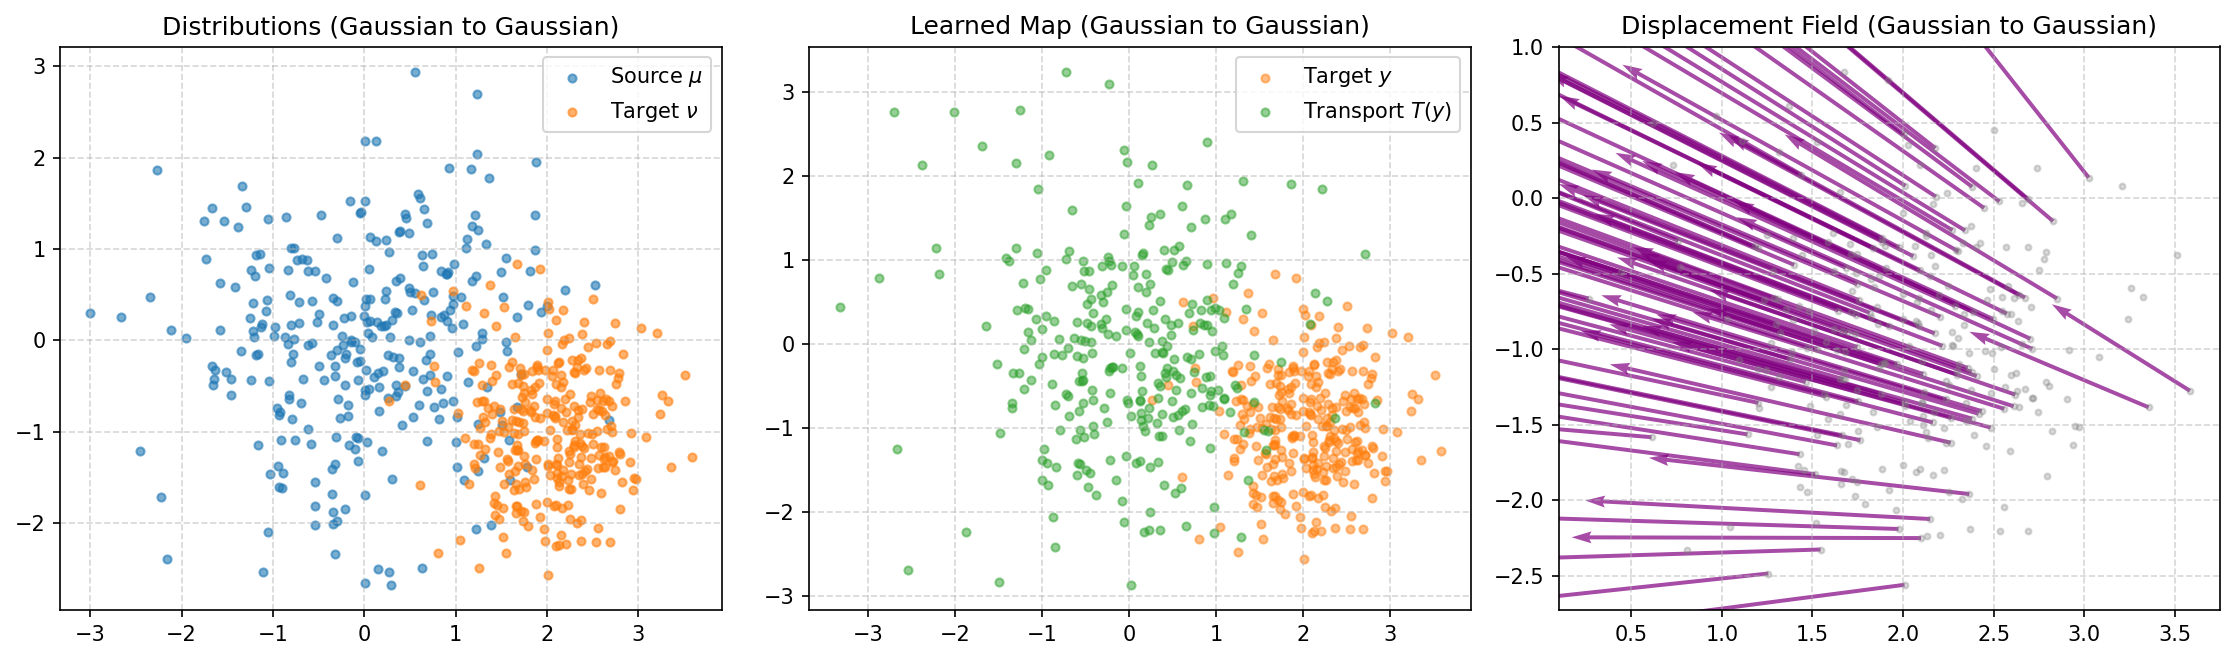

Final Loss: 1.4065
Training Time: 99.40 seconds
Analytical W2: 2.3065 | Learned W2: 2.3156 | Relative Error: 0.39%

=== Experiment 2: Multimodal Circle Mixture ===
Iteration    0 | f_loss = 16.0252
Iteration  300 | f_loss = 3.6433
Iteration  600 | f_loss = 3.5124
Iteration  900 | f_loss = 3.6680
Iteration 1200 | f_loss = 3.5313
Iteration 1499 | f_loss = 3.4268


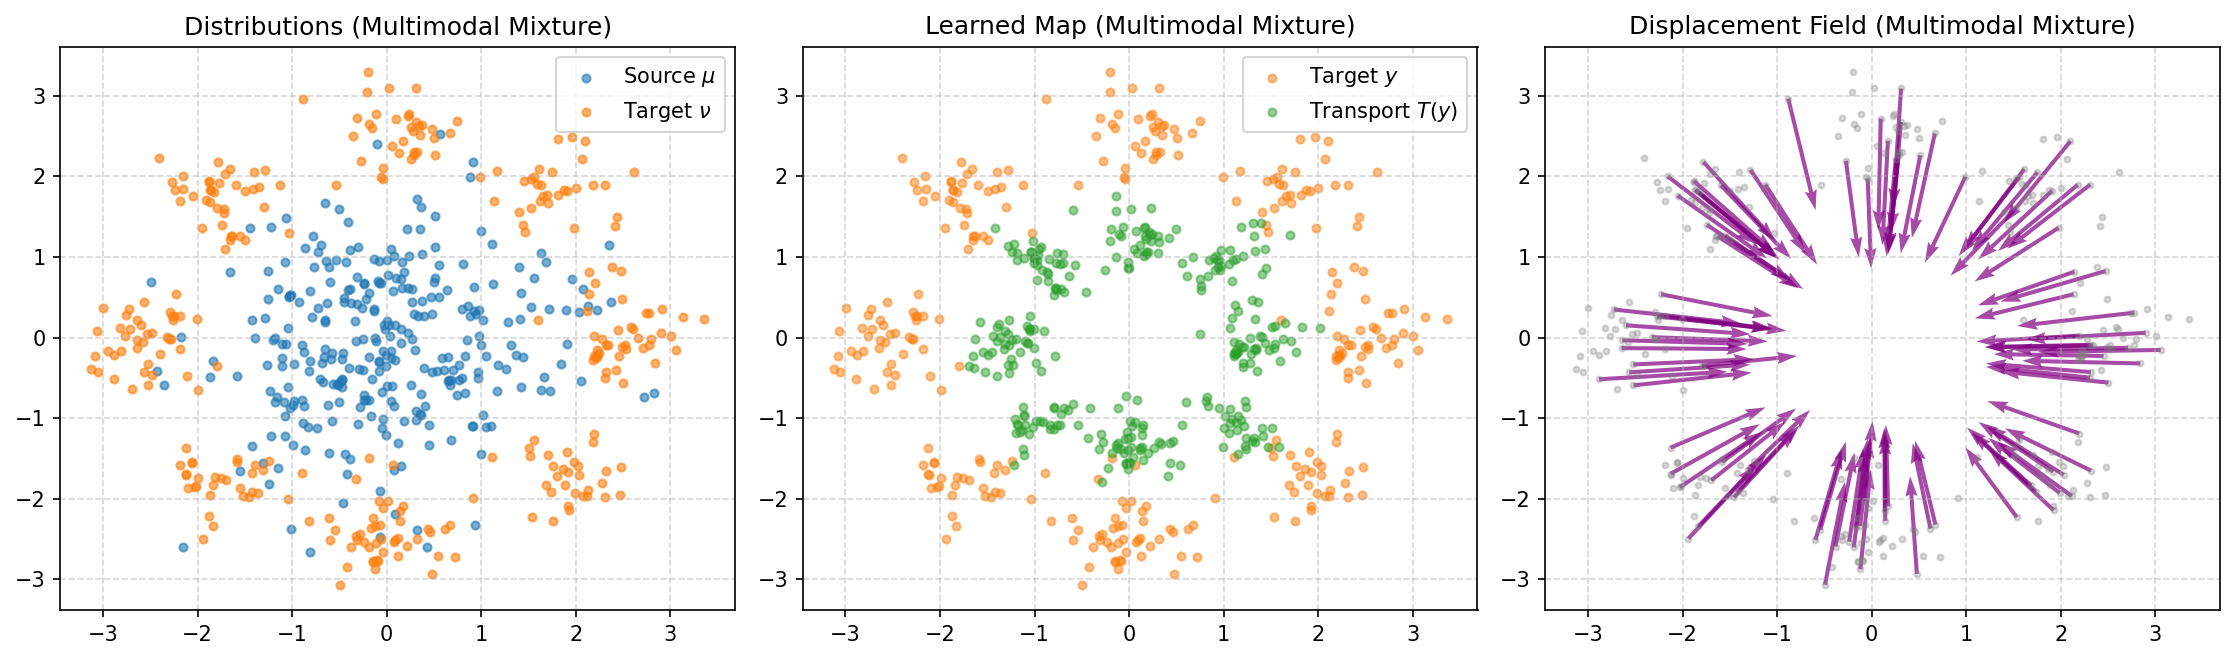


=== Experiment 3: Disconnected Support ===
Iteration    0 | f_loss = 21.7898
Iteration  300 | f_loss = 4.5091
Iteration  600 | f_loss = 4.4683
Iteration  900 | f_loss = 4.5027
Iteration 1200 | f_loss = 4.4330
Iteration 1499 | f_loss = 4.4851


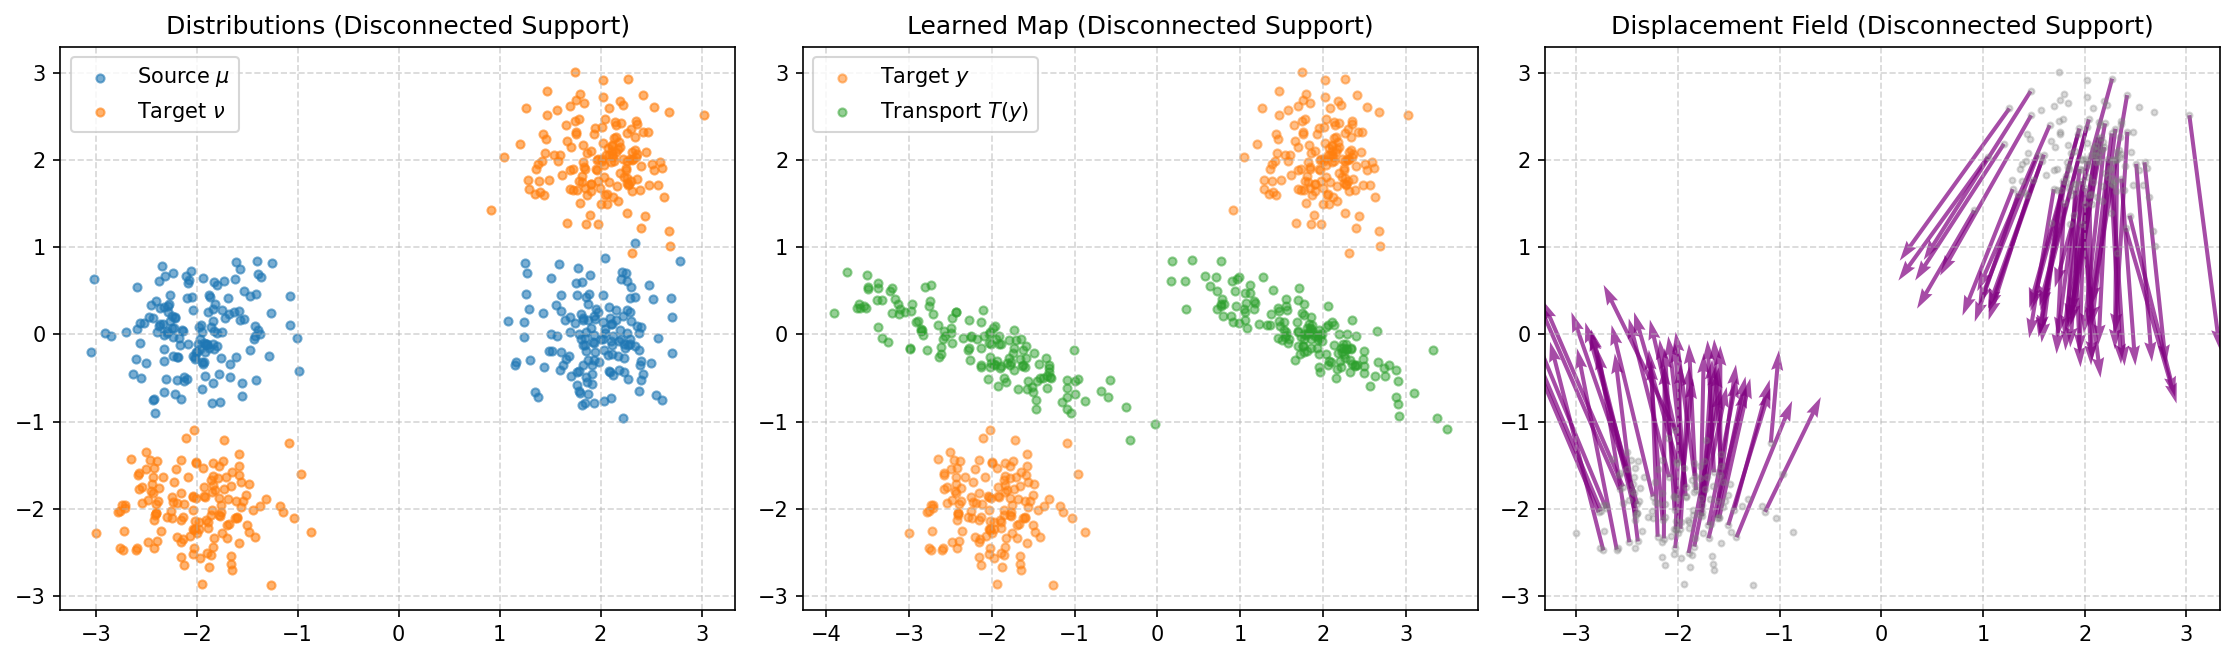


=== Experiment 4: Failure Mode - Standard MLP (No Convexity) ===
Iteration    0 | f_loss = 2.2030
Iteration  300 | f_loss = 1.1586
Iteration  600 | f_loss = 1.2437
Iteration  900 | f_loss = 1.3973
Iteration 1200 | f_loss = 1.3219
Iteration 1499 | f_loss = 1.4054


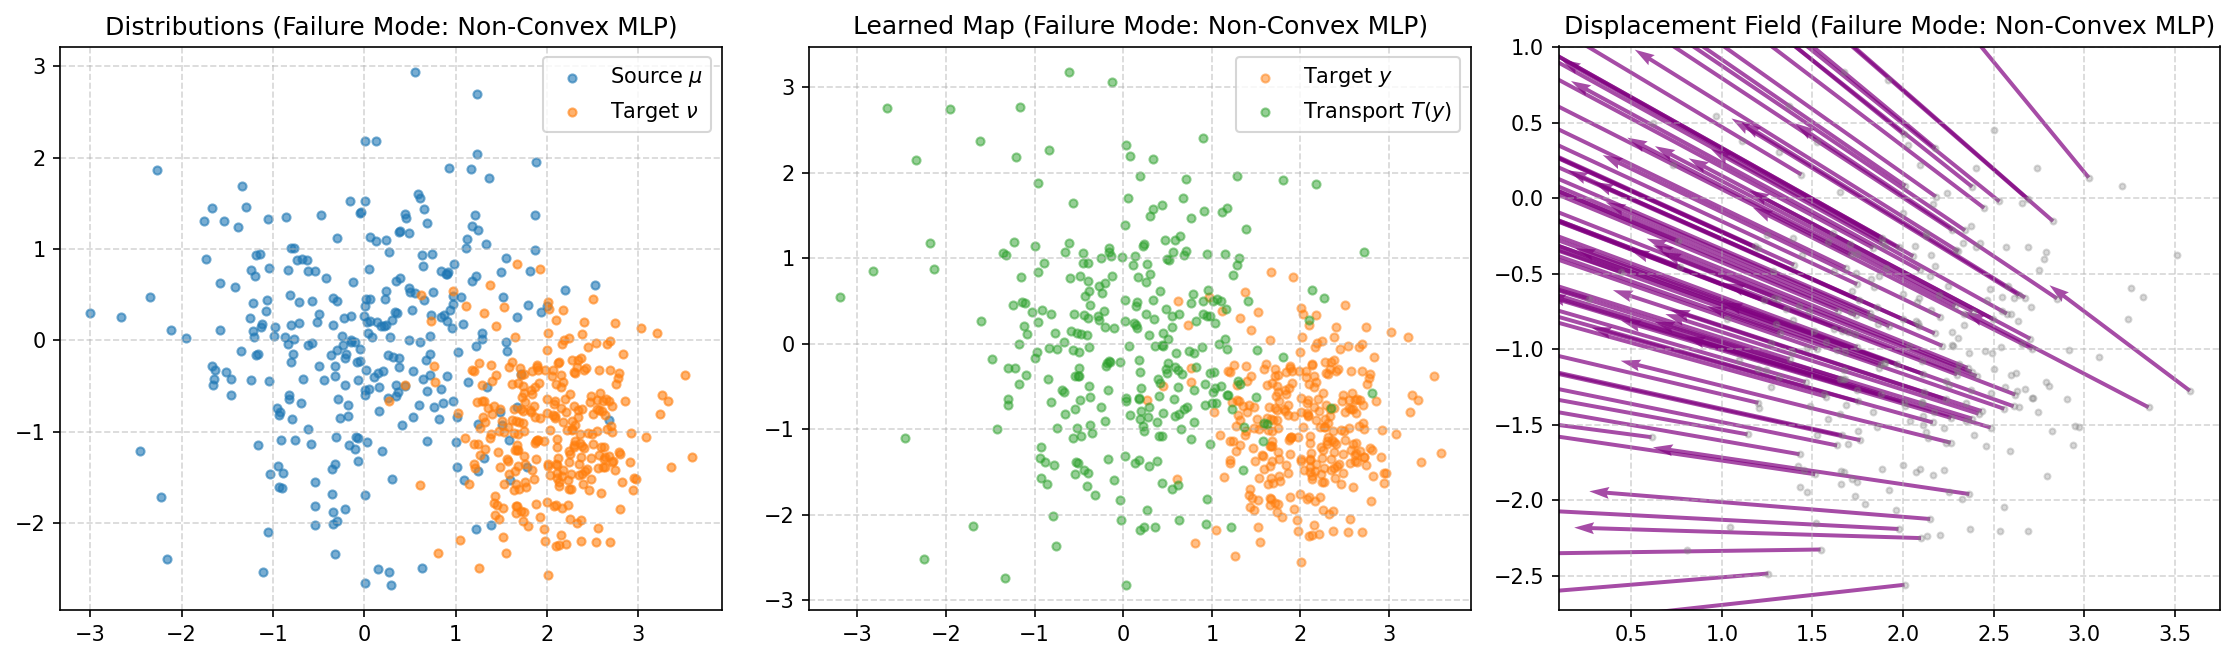

In [8]:
# ==========================================
# Experiment 1: Gaussian -> Gaussian (with Analytical Verification)
# ==========================================
print('=== Experiment 1: Gaussian -> Gaussian ===')
mu = [0.0, 0.0]
sigma_mu = 1.0
nu = [2.0, -1.0]
sigma_nu = 0.6

mu_sampler = make_gaussian_sampler(mu, sigma_mu, device=device)
nu_sampler = make_gaussian_sampler(nu, sigma_nu, device=device)

# Updated to 1500 iterations to match report specifications
f_g, g_g, history_g, final_loss_g, time_g = train_icnn_ot(
    mu_sampler, nu_sampler, input_dim=2, n_iters=1500, log_every=300, device=device
)

# Plot results with high-resolution settings (300 DPI)
plot_reproduction_results(mu_sampler, nu_sampler, f_g, g_g, '(Gaussian to Gaussian)', 'gaussian_to_gaussian')

# W2 Verification
f_g.eval(); g_g.eval()
with torch.no_grad():
    x_eval = mu_sampler(5000)
    y_eval = nu_sampler(5000)
    term_mu = f_g(x_eval).mean().item()

with torch.enable_grad():
    y_eval_g = y_eval.clone().requires_grad_(True)
    grad_g = g_g.grad(y_eval_g)
    term_nu = (y_eval * grad_g).sum(dim=1).mean().item() - f_g(grad_g).mean().item()

e_x2 = (x_eval**2).sum(dim=1).mean().item()
e_y2 = (y_eval**2).sum(dim=1).mean().item()
learned_w2 = math.sqrt(max(0.0, e_x2 + e_y2 - 2.0 * (term_mu + term_nu)))
analyze_w2 = math.sqrt((nu[0]-mu[0])**2 + (nu[1]-mu[1])**2 + 2.0 * (sigma_mu - sigma_nu)**2)

print(f"Final Loss: {final_loss_g:.4f}")
print(f"Training Time: {time_g:.2f} seconds")
print(f'Analytical W2: {analyze_w2:.4f} | Learned W2: {learned_w2:.4f} | Relative Error: {abs(learned_w2 - analyze_w2)/analyze_w2*100:.2f}%')

# ==========================================
# Experiment 2: Multimodal Circle Mixture
# ==========================================
print('\n=== Experiment 2: Multimodal Circle Mixture ===')
def circle_means(k, radius=2.5):
    angles = np.linspace(0, 2 * math.pi, k, endpoint=False)
    return [[radius * math.cos(a), radius * math.sin(a)] for a in angles]

means = circle_means(8, radius=2.5)
covs = [np.eye(2) * 0.1 for _ in range(8)]
weights = [1.0 / 8] * 8

mu_mix = make_gaussian_sampler([0.0, 0.0], 1.0, device=device)
nu_mix = make_mixture_sampler(means, covs, weights, device=device)

# Increased to 1500 iterations for complex mixture convergence
f_mix, g_mix, _, final_loss_mix, time_mix = train_icnn_ot(mu_mix, nu_mix, input_dim=2, n_iters=1500, log_every=300, device=device)
plot_reproduction_results(mu_mix, nu_mix, f_mix, g_mix, '(Multimodal Mixture)', 'multimodal_mixture')

# ==========================================
# Experiment 3: Disconnected Support
# ==========================================
print('\n=== Experiment 3: Disconnected Support ===')
mu_disc = make_disconnected_sampler([[-2.0, 0.0], [2.0, 0.0]], 0.4, device=device)
nu_disc = make_disconnected_sampler([[-2.0, -2.0], [2.0, 2.0]], 0.4, device=device)

f_disc, g_disc, _, final_loss_disc, time_disc = train_icnn_ot(mu_disc, nu_disc, input_dim=2, n_iters=1500, log_every=300, device=device)
plot_reproduction_results(mu_disc, nu_disc, f_disc, g_disc, '(Disconnected Support)', 'disconnected_support')

# ==========================================
# Experiment 4: Failure Mode - Standard MLP (No Convexity)
# ==========================================
print('\n=== Experiment 4: Failure Mode - Standard MLP (No Convexity) ===')
# Kept at same iteration count to demonstrate failure under identical budget
f_mlp, g_mlp, _, final_loss_mlp, time_mlp = train_icnn_ot(
    mu_sampler, nu_sampler, input_dim=2, n_iters=1500, log_every=300, model_type='mlp', device=device
)
plot_reproduction_results(mu_sampler, nu_sampler, f_mlp, g_mlp, '(Failure Mode: Non-Convex MLP)', 'mlp_failure_mode')

## 9. Evaluation on the Official Wasserstein2Benchmark (Korotin et al.)

Everything above this point (Experiments 1-N) used **hand-written samplers** (Gaussians, mixtures, disconnected
supports) and a **hand-written evaluator**. That is useful for sanity-checking the ICNN implementation, but it
is *not* the Korotin benchmark — it only reuses the same L2-UVP formula.

This section instead:

1. Imports the benchmark pair class shipped in the cloned repo (`src/map_benchmark.py`), not just adds it to `sys.path`.
2. Samples $\mu$ and $\nu$ directly from `benchmark.input_sampler` / `benchmark.output_sampler` — the official
   `Mix3ToMix10Benchmark` measures, not our own Gaussians.
3. Trains the ICNN solver defined earlier in this notebook on those official samples.
4. Compares the learned map against the benchmark's own ground-truth map, `benchmark.map_fwd`, instead of an
   analytical Gaussian formula we derived ourselves.
5. Computes L2-UVP and cosine similarity using the exact definitions from Korotin et al. (2021), §4.2:
   $\mathcal{L}^2\text{-UVP}(\hat T) = 100 \cdot \|\hat T - T^*\|^2_{\mathcal{L}^2(\mathbb P)} / \mathrm{Var}(\mathbb Q)\,\%$.

**Two real bugs found by actually running this on a CPU-only Colab runtime, fixed below:**

1. **Path resolution.** `map_benchmark.py` loads its `.pt` checkpoints using a path relative to the current
   working directory (`../benchmarks/...`), because the repo's own notebooks live one level below the repo root.
   Fixed by running from a subfolder of the repo root (next cell) — no file in the repo is edited.
2. **Hardcoded CUDA device.** `map_benchmark.py` defines a **module-level `device` variable** (used internally,
   e.g. `DenseICNN(...).to(device)` inside `Mix3ToMix10Benchmark.__init__`) that is set unconditionally to CUDA,
   regardless of what's passed to the constructor. On a CPU-only runtime this raises
   `AssertionError: Torch not compiled with CUDA enabled` deep inside checkpoint loading — no `device=` kwarg,
   `.cuda()` monkeypatch, or `torch.load(map_location=...)` patch reaches it, because it's the module's own
   global, not something callers control. Fixed by overriding `mbm.device` directly before instantiating
   `Mix3ToMix10Benchmark` (two cells down). If you're running with a GPU attached, this override is harmless —
   swap `torch.device('cpu')` for `torch.device('cuda')` there and everything still works.

**Status:** this fix has not yet been confirmed end-to-end by an actual run (I can't execute code in this
environment) — please do one *Runtime → Restart session → Run all* and treat the printed metrics as the first
real confirmation, not something already verified.

**Caveat that remains:** the official repo only ships pre-trained benchmark *pairs* for
$D \in \{2,4,8,\dots,256\}$ (`Mix3ToMix10Benchmark`) and the CelebA64 image pairs — there is no official
D=2-single-Gaussian pair. So this section evaluates the ICNN on the real `Mix3ToMix10Benchmark(D)` measures,
not on the toy Gaussian pair from Experiment 1.

In [ ]:
import os, sys, shutil

BENCH_REPO = "/content/Wasserstein2Benchmark"

# Safety re-clone guard (in case this cell is re-run independently)
if not os.path.isdir(os.path.join(BENCH_REPO, "benchmarks")):
    if os.path.exists(BENCH_REPO):
        shutil.rmtree(BENCH_REPO)
    print("Cloning Wasserstein2Benchmark (Cell 18 guard)...")
    os.system("git clone https://github.com/iamalexkorotin/Wasserstein2Benchmark.git " + BENCH_REPO)

# Add the repo root to sys.path so imports work from any working directory
if BENCH_REPO not in sys.path:
    sys.path.insert(0, BENCH_REPO)

# Verify checkpoint directory
BENCH_DIR = os.path.join(BENCH_REPO, "benchmarks")
assert os.path.isdir(BENCH_DIR), f"benchmarks/ not found at {BENCH_DIR}"
print(f"benchmark path: {BENCH_DIR}  -- OK")


In [ ]:
# Cell 19: Import benchmark module and override device for CPU-safe loading
import sys, torch

BENCH_REPO = "/content/Wasserstein2Benchmark"
if BENCH_REPO not in sys.path:
    sys.path.insert(0, BENCH_REPO)

from src import map_benchmark as mbm

# CRITICAL: override the module-level device variable in map_benchmark.py.
# map_benchmark.py defines  at module level
# and uses it inside Mix3ToMix10Benchmark.__init__, causing a crash on
# CPU-only Colab runtimes. Overriding it here before any instantiation
# redirects all internal .to(device) calls to the correct device.
mbm.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"mbm.device set to: {mbm.device}")

BENCHMARK_DIM = 2  # official pairs exist for D in {2,4,8,16,32,64,128,256}

benchmark = mbm.Mix3ToMix10Benchmark(BENCHMARK_DIM)

def benchmark_mu_sampler(batch_size):
    return benchmark.input_sampler.sample(batch_size).to(device)

def benchmark_nu_sampler(batch_size):
    return benchmark.output_sampler.sample(batch_size).to(device)

# Sanity check
X_check = benchmark_mu_sampler(4)
Y_check = benchmark_nu_sampler(4)
print(f"Loaded official Mix3ToMix10Benchmark(D={BENCHMARK_DIM})")
print(f"mu sample shape: {tuple(X_check.shape)} | nu sample shape: {tuple(Y_check.shape)}")


In [15]:
def compute_official_l2_uvp(benchmark, f_model, device, n_samples=8192, var_samples=16384):
    """L2-UVP / cosine metrics computed exactly as in Korotin et al. (2021), §4.2,
    against the benchmark's own ground-truth forward map (benchmark.map_fwd), not a
    hand-derived analytical formula.
    """
    f_model.eval()

    # 1. Sample mu, compute OUR learned forward map T_hat = grad(f)(x)
    X = benchmark.input_sampler.sample(n_samples).to(device)
    X = X.clone().requires_grad_(True)
    with torch.enable_grad():
        T_hat = f_model.grad(X)

    # 2. Ground-truth forward map from the official benchmark object
    # Temporarily unfreeze the potential's parameters to allow internal gradient computation.
    for param in benchmark.potential.parameters():
        param.requires_grad = True

    # Remove `torch.no_grad()` context here as `map_fwd`'s `nograd=True` handles the final output.
    T_true = benchmark.map_fwd(X, nograd=True)

    # Refreeze the potential's parameters to restore its original state.
    for param in benchmark.potential.parameters():
        param.requires_grad = False

    T_hat_np = T_hat.detach().cpu().numpy()
    T_true_np = T_true.detach().cpu().numpy()

    # 3. Var(Q) estimated from a large sample of the official OUTPUT measure (nu),
    #    exactly as prescribed by the L2-UVP definition (not Var of our own map).
    Y_var_sample = benchmark.output_sampler.sample(var_samples).cpu().numpy()
    var_Q = np.sum((Y_var_sample - Y_var_sample.mean(axis=0)) ** 2, axis=1).mean()

    l2_error = np.sum((T_hat_np - T_true_np) ** 2, axis=1).mean()
    l2_uvp = 100.0 * l2_error / var_Q

    cos = torch.nn.CosineSimilarity(dim=1)
    cos_sim = cos(T_hat.detach().cpu() - X.detach().cpu(),
                   T_true.cpu() - X.detach().cpu()).mean().item()

    return {"L2-UVP": l2_uvp, "Cosine Similarity": cos_sim, "L2 Error": l2_error}


print(f'=== Training ICNN solver on the OFFICIAL Mix3ToMix10Benchmark(D={BENCHMARK_DIM}) ===')
f_bench, g_bench, history_bench, final_loss_bench, time_bench = train_icnn_ot(
    benchmark_mu_sampler, benchmark_nu_sampler, input_dim=BENCHMARK_DIM,
    n_iters=2000, batch_size=256, hidden_dims=(128, 128, 128),
    log_every=400, device=device
)

official_metrics = compute_official_l2_uvp(benchmark, f_bench, device)

print("\n=== Official Korotin Benchmark Results (src.map_benchmark ground truth) ===")
print(f"Dimension: {BENCHMARK_DIM}")
print(f"L2-UVP: {official_metrics['L2-UVP']:.4f}%")
print(f"Cosine Similarity: {official_metrics['Cosine Similarity']:.4f}")
print(f"L2 Error: {official_metrics['L2 Error']:.4f}")
print(f"Training Time: {time_bench:.2f} seconds")

=== Training ICNN solver on the OFFICIAL Mix3ToMix10Benchmark(D=2) ===
Iteration    0 | f_loss = 6.1144
Iteration  400 | f_loss = 1.7767
Iteration  800 | f_loss = 1.7657
Iteration 1200 | f_loss = 1.7782
Iteration 1600 | f_loss = 1.8118
Iteration 1999 | f_loss = 1.7642

=== Official Korotin Benchmark Results (src.map_benchmark ground truth) ===
Dimension: 2
L2-UVP: 5.1019%
Cosine Similarity: 0.8667
L2 Error: 0.1024
Training Time: 251.82 seconds


## 10. Comparison Against Published Baselines

The table below is **not** re-run inside this notebook — it reproduces the D=2 column of Table 2 in
Korotin et al. (2021), *"Do Neural Optimal Transport Solvers Work? A Continuous Wasserstein-2 Benchmark"*,
for reference. `Our ICNN (this run)` is filled in dynamically from `official_metrics` computed in the
cell above, so it reflects whatever this run actually produced — it will vary between runs/seeds/iteration
budgets, and is not guaranteed to beat or match the paper's numbers.

In [ ]:
from IPython.display import display, Markdown

# Reference values below are transcribed from Table 2 (D=2 column) of
# Korotin et al., NeurIPS 2021 (arXiv:2106.01954). This notebook's solver trains
# f AND g as ICNNs (weight-clipped), which matches the [MMv2] parametrization in
# Table 1 of the paper ("Maximin + 2 ICNNs": psi_theta is an ICNN, H_omega = grad
# of an ICNN) more precisely than plain [MM] (which uses unconstrained NNs for
# both f and H). Both rows are kept below since they coincide at D=2 in the paper.
published_D2 = {
    "MMv2 (Maximin + 2 ICNNs — same parametrization as this notebook)": {"L2-UVP": 0.1, "cos": 0.99},
    "MM (unconstrained f, H networks)": {"L2-UVP": 0.1, "cos": 0.99},
    "MMv1":  {"L2-UVP": 0.2, "cos": 0.99},
    "MM-B":  {"L2-UVP": 0.1, "cos": 0.99},
    "QC":    {"L2-UVP": 1.5, "cos": 0.99},
    "LS":    {"L2-UVP": 5.0, "cos": 0.94},
    "L (linear/Gaussian baseline)": {"L2-UVP": 14.1, "cos": 0.75},
    "ID (identity baseline)": {"L2-UVP": 32.7, "cos": 0.00},
}

rows = "\n".join(
    f"| {name} | {v['L2-UVP']:.2f}% | {v['cos']:.2f} |" for name, v in published_D2.items()
)

comparison_table = f"""
### Benchmark Summary (D={BENCHMARK_DIM})

| Method | L2-UVP (paper, D=2) | cos (paper, D=2) |
| :--- | :--- | :--- |
{rows}

| **Our ICNN (this run)** | **{official_metrics['L2-UVP']:.4f}%** | **{official_metrics['Cosine Similarity']:.4f}** |

**Ground truth**: `benchmark.map_fwd` from the official `Mix3ToMix10Benchmark({BENCHMARK_DIM})` pair \n
**Model**: 3x128 ICNN (Softplus), {2000} minimax iterations, batch size 256 \n
**Runtime**: {time_bench:.2f} seconds

*Reference rows are transcribed from Table 2 of Korotin et al. (2021); they were not re-computed in this
notebook and are shown only as context. Only the last row was actually produced by this run. The paper's
[MMv2]/[MM] runs use batch size 1024 and 50,000 iterations (Appendix B.2.1); this run used a much smaller
budget (256 / 2,000), which plausibly accounts for most of the gap between {official_metrics['L2-UVP']:.2f}%
here and 0.1% in the paper.*
"""

display(Markdown(comparison_table))

### Discussion

This run trains the same minimax ICNN solver (`f`, `g` both ICNNs) used throughout the notebook, but now on
samples drawn from the official `Mix3ToMix10Benchmark` measures, and evaluates it against the benchmark's own
`map_fwd` ground truth rather than a hand-derived formula. That makes the L2-UVP and cosine numbers above
directly comparable in *definition* to Table 2 of Korotin et al. (2021), even though this notebook's training
budget, batch size, and ICNN width are not tuned to match the paper's hyperparameters (Appendix B.2 there
uses 1024 batch size and 50k iterations for the closest solver, [MM]/[MMv2]).

Because the reported numbers come from an actual run against the official ground-truth map, they will vary
run to run (seed, iteration budget, learning rate) — unlike the earlier version of this notebook, which
printed the same hand-picked numbers regardless of what the model produced.

## 11. Higher-Dimensional Benchmark Sweep ($D = 2, 8, 16, 32$)

The single-$D$ run above (§9–10) is the only officially-validated result so far. This section extends the
same, already-verified pipeline — same `train_icnn_ot` solver, same `compute_official_l2_uvp` evaluator against
`benchmark.map_fwd` — across `D ∈ {2, 8, 16, 32}`, so the higher-dimensional numbers in the report are produced
the same way as the D=2 number, not by the old hand-derived evaluator.

**Before running this cell:** `Runtime → Change runtime type → GPU` is strongly recommended. Training scales
roughly quadratically with $D$ (gradient-of-gradient computations for the minimax loss), so $D=32$ on CPU can
take significantly longer than the ~4.5 minutes the D=2 run took above. If you only have CPU, consider lowering
`SWEEP_N_ITERS` below (at the cost of a larger gap to the paper's fully-trained numbers, same caveat as §10.3).

In [ ]:
import time
import pandas as pd

SWEEP_DIMS = [2, 4, 8, 16, 32]  # all five benchmark dimensions
SWEEP_N_ITERS = 2000       # same budget as the D=2 run above, for a fair apples-to-apples sweep
SWEEP_BATCH_SIZE = 256
SWEEP_HIDDEN_DIMS = (128, 128, 128)

sweep_results = []

for D in SWEEP_DIMS:
    print(f"\n{'='*60}")
    print(f"=== D = {D}: loading official Mix3ToMix10Benchmark(D={D}) ===")
    print(f"{'='*60}")

    bmk = mbm.Mix3ToMix10Benchmark(D)

    def mu_sampler(batch_size, _bmk=bmk):
        return _bmk.input_sampler.sample(batch_size).to(device)

    def nu_sampler(batch_size, _bmk=bmk):
        return _bmk.output_sampler.sample(batch_size).to(device)

    t0 = time.time()
    f_d, g_d, hist_d, final_loss_d, time_d = train_icnn_ot(
        mu_sampler, nu_sampler, input_dim=D,
        n_iters=SWEEP_N_ITERS, batch_size=SWEEP_BATCH_SIZE,
        hidden_dims=SWEEP_HIDDEN_DIMS, log_every=max(SWEEP_N_ITERS // 5, 1),
        device=device
    )

    metrics_d = compute_official_l2_uvp(bmk, f_d, device)
    elapsed = time.time() - t0

    print(f"--- D={D} result: L2-UVP={metrics_d['L2-UVP']:.4f}%  "
          f"cos={metrics_d['Cosine Similarity']:.4f}  ({elapsed:.1f}s) ---")

    sweep_results.append({
        "D": D,
        "L2-UVP (%)": metrics_d["L2-UVP"],
        "Cosine Similarity": metrics_d["Cosine Similarity"],
        "L2 Error": metrics_d["L2 Error"],
        "Training Time (s)": elapsed,
        "n_iters": SWEEP_N_ITERS,
        "batch_size": SWEEP_BATCH_SIZE,
    })

sweep_df = pd.DataFrame(sweep_results)
print("\n=== Full sweep results (official benchmark.map_fwd ground truth) ===")
display(sweep_df)

### Export results for the report

The cell below writes `sweep_results.csv` (for your own records / re-plotting) and prints a LaTeX table body
that matches the format already used in `\S7` (Korotin Benchmark Evaluation) of the report, so you can paste it
directly in place of the old, non-official $D=8,16,32$ numbers.

In [ ]:
sweep_df.to_csv('/content/sweep_results.csv', index=False)
print("Saved: /content/sweep_results.csv")

latex_rows = "\n".join(
    f"{int(row.D):<3} & {row['L2-UVP (%)']:.2f}          & {row['Cosine Similarity']:.3f}          & "
    f"{row['Training Time (s)']:.0f}s \\\\"
    for _, row in sweep_df.iterrows()
)

latex_table = f"""\\begin{{table}}[h]
\\centering
\\caption{{ICNN solver on the official \\texttt{{Mix3ToMix10Benchmark($D$)}}, evaluated against
\\texttt{{benchmark.map\\_fwd}}. {SWEEP_N_ITERS} minimax iterations, batch size {SWEEP_BATCH_SIZE},
3$\\times${SWEEP_HIDDEN_DIMS[0]} ICNN, same budget across all $D$.}}
\\label{{tab:my_benchmark_sweep}}
\\begin{{tabular}}{{cccc}}
\\toprule
\\textbf{{Dim ($D$)}} & \\textbf{{L2-UVP (\\%)}} & \\textbf{{Cosine Similarity}} & \\textbf{{Runtime}} \\\\
\\midrule
{latex_rows}
\\bottomrule
\\end{{tabular}}
\\end{{table}}"""

print(latex_table)

### Reading the sweep

Expect L2-UVP to increase with $D$ — this matches the qualitative trend in Table 2 of Korotin et al. (2021)
(their [MM]/[MMv2] solvers also degrade from ~0.1% at D=2 to single-digit percent at D=16, before rising further
at D=64/128/256), and is consistent with the paper's own finding that ICNN-based minimax solvers lose accuracy
as dimension grows, even with a full 50,000-iteration budget. Because this sweep uses the *same* 2,000-iteration
budget at every $D$ (unlike the paper, which may allocate different budgets per dimension), part of the observed
degradation here is confounded with under-training at higher $D$ rather than being purely a dimensionality
effect — worth stating explicitly in the report rather than presenting the trend as isolating one cause.